# SARIMA / SARIMAX Forecasting — One-Week-Ahead Dengue Cases

This notebook provides the **traditional time-series comparator** for the Maynas dengue forecasting project.

## Active forecasting scope

- **Outcome:** weekly dengue case count
- **Forecast horizon:** one week ahead
- **Target week:** week `t`
- **Information availability:** predictors must be available by the end of week `t-1`
- **Weekly convention:** Sunday–Saturday, identified by Sunday `week_start_date`
- **Training:** 2000–2017
- **Validation:** 2018–2020
- **Final test:** 2021–2023, held back from model development

Two related models are examined:

1. **SARIMA** — dengue history and seasonal structure only.
2. **SARIMAX** — the same time-series structure plus selected lagged/rolling environmental predictors.

The notebook uses **rolling one-week-ahead validation forecasts**. After forecasting each validation week, the actual dengue observation is supplied to the state-space model before forecasting the next week. This matches the project's one-week-ahead forecasting question more closely than making one uninterrupted three-year forecast from the end of 2017.

## 1. Setup and data loading

Input:

`data/processed/modelling/maynas_dengue_features_1w_ahead.csv`

The engineered feature dataset has already passed an independent audit confirming true calendar-week lagging and no target-week environmental leakage.

`statsmodels` is required for SARIMA/SARIMAX.

In [30]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

try:
    from statsmodels.tsa.statespace.sarimax import SARIMAX
    STATSMODELS_AVAILABLE = True
except ImportError:
    STATSMODELS_AVAILABLE = False

warnings.filterwarnings(
    "ignore",
    message="Non-stationary starting autoregressive parameters"
)
warnings.filterwarnings(
    "ignore",
    message="Non-invertible starting MA parameters"
)

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 170)

PROJECT_ROOT = Path.cwd().resolve().parent

DATA_FILE = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "modelling"
    / "maynas_dengue_features_1w_ahead.csv"
)

OUTPUT_DIR = PROJECT_ROOT / "outputs" / "modelling"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_FILE)

df["week_start_date"] = pd.to_datetime(
    df["week_start_date"],
    errors="raise"
)

df = (
    df
    .sort_values("week_start_date")
    .reset_index(drop=True)
)

print(f"Rows: {len(df):,}")
print(f"Statsmodels available: {STATSMODELS_AVAILABLE}")

Rows: 1,248
Statsmodels available: True


In [31]:
if not STATSMODELS_AVAILABLE:
    print(
        "statsmodels is not installed in the selected environment.\n"
        "Install it into dengue-venv with:\n\n"
        '& "$env:LOCALAPPDATA\\dengue-venv\\Scripts\\python.exe" '
        '-m pip install statsmodels'
    )

## 2. Reconstruct the complete weekly calendar

The dengue source contains four known missing surveillance weeks in 2000. A SARIMA model should operate on a **regular weekly timeline**, so the observed feature table is reindexed to every Sunday.

Missing dengue surveillance weeks remain `NaN`. `statsmodels` can handle missing endogenous observations through its state-space/Kalman-filter formulation.

For SARIMAX, exogenous predictors cannot contain missing values. The engineered feature table has a small number of structural missing values around the start of the series and the four dengue gaps. For historical fitting only, environmental exogenous features are carried forward from the most recent available past value after reindexing. Leading rows before any historical exogenous value exists are removed.

This imputation is:

- confined to model inputs, not the dengue target;
- based only on past information;
- needed to retain a regular weekly SARIMAX timeline;
- not used during the 2018–2020 validation period, where the selected environmental features are complete.

In [32]:
calendar = pd.date_range(
    start=df["week_start_date"].min(),
    end=df["week_start_date"].max(),
    freq="W-SUN"
)

weekly = (
    df
    .set_index("week_start_date")
    .reindex(calendar)
)

weekly.index.name = "week_start_date"

print(f"Complete calendar weeks: {len(weekly):,}")
print(f"Observed dengue weeks:   {weekly['dengue_cases'].notna().sum():,}")
print(f"Missing dengue weeks:    {weekly['dengue_cases'].isna().sum():,}")

Complete calendar weeks: 1,252
Observed dengue weeks:   1,248
Missing dengue weeks:    4


### Interpretation — weekly calendar reconstruction

The complete weekly calendar contains **1,252 Sunday-based weeks**, of which **1,248 have observed dengue case counts**. The remaining four weeks are the previously documented surveillance gaps.

Retaining those weeks as missing observations is important for SARIMA/SARIMAX because the models assume a regular temporal structure. Treating the previous observed row as the previous week would distort lag timing around the gaps.

This reconstruction therefore preserves the real calendar while avoiding the incorrect assumption that the four absent surveillance weeks represented zero dengue cases.


## 3. Fixed development split and benchmarks

The final 2021–2023 test period remains untouched.

Current validation benchmarks from the earlier notebooks are:

- Persistence: **MAE 11.21**, RMSE 26.62
- Ridge history + seasonality: **MAE 13.17**, RMSE 25.33
- Best XGBoost history-only: **MAE 10.56**, RMSE 21.10
- Best XGBoost climate-enhanced: **MAE 11.20**, RMSE 21.56

In [33]:
TRAIN_END = pd.Timestamp("2017-12-31")
VALIDATION_START = pd.Timestamp("2018-01-01")
VALIDATION_END = pd.Timestamp("2020-12-31")
TEST_START = pd.Timestamp("2021-01-01")

development = weekly.loc[
    weekly.index <= VALIDATION_END
].copy()

train = development.loc[
    development.index <= TRAIN_END
].copy()

validation = development.loc[
    (development.index >= VALIDATION_START)
    & (development.index <= VALIDATION_END)
].copy()

reserved_test = weekly.loc[
    weekly.index >= TEST_START
].copy()

print(f"Training calendar weeks:   {len(train):,}")
print(f"Validation calendar weeks: {len(validation):,}")
print(f"Reserved test weeks:       {len(reserved_test):,}")
print(f"Validation target missing: {validation['dengue_cases'].isna().sum():,}")

Training calendar weeks:   940
Validation calendar weeks: 156
Reserved test weeks:       156
Validation target missing: 0


### Interpretation — development split

The training period contains **940 calendar weeks**, while validation and the reserved final test each contain **156 weeks**.

There are no missing dengue targets in the 2018–2020 validation period, so all validation weeks can be evaluated consistently.

The 2021–2023 test period remains untouched. This is essential because all order selection and model comparison below must be based only on training and validation performance.


## 4. Metrics

In [34]:
def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
    }

## 5. Candidate SARIMA structures

The search is deliberately small to keep the analysis proportionate and interpretable.

All models use weekly seasonal period **52**. The candidate structures vary only a small number of autoregressive/moving-average terms.

In [35]:
SARIMA_CONFIGS = [
    {
        "name": "SARIMA_1",
        "order": (1, 0, 0),
        "seasonal_order": (1, 0, 0, 52),
    },
    {
        "name": "SARIMA_2",
        "order": (2, 0, 0),
        "seasonal_order": (1, 0, 0, 52),
    },
    {
        "name": "SARIMA_3",
        "order": (1, 0, 1),
        "seasonal_order": (1, 0, 0, 52),
    },
]

pd.DataFrame(SARIMA_CONFIGS)

,name,order,seasonal_order
0,SARIMA_1,"(1, 0, 0)","(1, 0, 0, 52)"
1,SARIMA_2,"(2, 0, 0)","(1, 0, 0, 52)"
2,SARIMA_3,"(1, 0, 1)","(1, 0, 0, 52)"


## 6. Rolling one-week-ahead forecasting helper

Each model is fitted once on the 2000–2017 training period.

For each validation week:

1. forecast exactly one week ahead;
2. store the prediction;
3. append the actual observed dengue count to the model state **without refitting parameters**;
4. move to the next week.

In [36]:
def rolling_one_step_forecast(
    fitted_result,
    validation_endog,
    validation_exog=None,
):
    """
    Produce rolling one-week-ahead forecasts.

    Important:
    statsmodels requires appended endogenous data to preserve the same
    column/name structure as the series used when the model was fitted.
    """
    predictions = []
    result = fitted_result

    endog_name = validation_endog.name

    for date in validation_endog.index:

        if validation_exog is None:
            forecast = result.get_forecast(steps=1)
        else:
            exog_row = validation_exog.loc[[date]].copy()

            forecast = result.get_forecast(
                steps=1,
                exog=exog_row,
            )

        prediction = float(
            np.asarray(
                forecast.predicted_mean
            ).reshape(-1)[0]
        )

        predictions.append(
            {
                "week_start_date": date,
                "prediction_raw": prediction,
            }
        )

        actual = validation_endog.loc[date]

        # Preserve the original endogenous variable name so statsmodels
        # can concatenate the new observation with the fitted model data.
        new_endog = pd.Series(
            [actual],
            index=pd.DatetimeIndex([date]),
            name=endog_name,
            dtype=float,
        )

        if validation_exog is None:
            result = result.append(
                endog=new_endog,
                refit=False,
            )
        else:
            new_exog = validation_exog.loc[[date]].copy()

            result = result.append(
                endog=new_endog,
                exog=new_exog,
                refit=False,
            )

    prediction_df = pd.DataFrame(
        predictions
    )

    prediction_df["prediction"] = np.clip(
        prediction_df["prediction_raw"],
        a_min=0,
        a_max=None,
    )

    return prediction_df


## 7. Fit and validate SARIMA

In [37]:
sarima_results = []
sarima_predictions = {}
sarima_models = {}

if STATSMODELS_AVAILABLE:

    train_endog = train["dengue_cases"].astype(float)
    validation_endog = validation["dengue_cases"].astype(float)

    for config in SARIMA_CONFIGS:

        print(f"Fitting {config['name']} ...")

        model = SARIMAX(
            train_endog,
            order=config["order"],
            seasonal_order=config["seasonal_order"],
            trend="c",
            enforce_stationarity=False,
            enforce_invertibility=False,
        )

        fitted = model.fit(
            disp=False,
            maxiter=200,
        )

        pred_df = rolling_one_step_forecast(
            fitted,
            validation_endog,
        )

        pred_df["dengue_cases"] = validation_endog.values
        pred_df["residual"] = (
            pred_df["dengue_cases"]
            - pred_df["prediction"]
        )

        metrics = regression_metrics(
            pred_df["dengue_cases"],
            pred_df["prediction"],
        )

        sarima_results.append(
            {
                "algorithm": "SARIMA",
                "configuration": config["name"],
                "order": str(config["order"]),
                "seasonal_order": str(config["seasonal_order"]),
                **metrics,
                "AIC": fitted.aic,
                "BIC": fitted.bic,
            }
        )

        sarima_predictions[config["name"]] = pred_df
        sarima_models[config["name"]] = fitted

    sarima_results_df = (
        pd.DataFrame(sarima_results)
        .sort_values("MAE")
        .reset_index(drop=True)
    )

    display(sarima_results_df)

Fitting SARIMA_1 ...
Fitting SARIMA_2 ...
Fitting SARIMA_3 ...


,algorithm,configuration,order,seasonal_order,MAE,RMSE,R2,AIC,BIC
0,SARIMA,SARIMA_1,"(1, 0, 0)","(1, 0, 0, 52)",12.055635,26.210620,0.864668,10341.569381,10360.720761
1,SARIMA,SARIMA_3,"(1, 0, 1)","(1, 0, 0, 52)",12.057681,26.386259,0.862848,10341.807328,10365.746553
2,SARIMA,SARIMA_2,"(2, 0, 0)","(1, 0, 0, 52)",12.162887,26.494423,0.861721,10330.128102,10354.061687


In [38]:
if STATSMODELS_AVAILABLE:
    best_sarima = sarima_results_df.iloc[0]
    print("Best SARIMA by validation MAE:")
    display(best_sarima.to_frame().T)

Best SARIMA by validation MAE:


,algorithm,configuration,order,seasonal_order,MAE,RMSE,R2,AIC,BIC
0,SARIMA,SARIMA_1,"(1, 0, 0)","(1, 0, 0, 52)",12.055635,26.21062,0.864668,10341.569381,10360.720761


### Interpretation — SARIMA results

The three SARIMA structures perform similarly, but **SARIMA_1** is the preferred traditional model by validation MAE.

Its specification is:

- non-seasonal order: `(1, 0, 0)`
- seasonal order: `(1, 0, 0, 52)`

Validation performance:

- **MAE: 12.06**
- **RMSE: 26.21**
- **R²: 0.865**

This is a credible traditional benchmark. It is only slightly worse than the persistence baseline on MAE (11.21), while its RMSE is slightly better than persistence (26.62).

The differences between the three SARIMA candidates are small, which suggests that increasing autoregressive or moving-average complexity does not materially improve one-week-ahead forecasting in this development period.


## 8. SARIMAX environmental specification

SARIMAX uses the same time-series structure as SARIMA but adds a compact environmental exogenous set.

The selected exogenous variables are already lagged or historical rolling features, so their values are available before the target week.

In [39]:
SARIMAX_EXOG = [
    "precip_sum_mm_lag1",
    "precip_sum_mm_prev4w_sum",
    "temperature_c_mean_lag1",
    "specific_humidity_kgkg_mean_lag1",
    "relative_humidity_pct_mean_prev4w_mean",
    "wind_speed_ms_mean_lag1",
    "surface_pressure_hpa_mean_lag8",
    "ndvi_mean_weekly_lag1",
]

missing_exog = [
    col
    for col in SARIMAX_EXOG
    if col not in weekly.columns
]

if missing_exog:
    raise ValueError(
        "Missing SARIMAX exogenous feature(s): "
        + ", ".join(missing_exog)
    )

SARIMAX_EXOG

['precip_sum_mm_lag1',
 'precip_sum_mm_prev4w_sum',
 'temperature_c_mean_lag1',
 'specific_humidity_kgkg_mean_lag1',
 'relative_humidity_pct_mean_prev4w_mean',
 'wind_speed_ms_mean_lag1',
 'surface_pressure_hpa_mean_lag8',
 'ndvi_mean_weekly_lag1']

### Prepare exogenous data

Forward filling occurs only after the calendar has been reconstructed, so missing historical exogenous entries are filled from earlier information rather than future values.

Any leading period before all selected exogenous variables first become available is excluded from SARIMAX fitting.

In [40]:
exog_all = weekly[SARIMAX_EXOG].copy()
exog_filled = exog_all.ffill()

first_complete_exog_date = exog_filled.dropna().index.min()

print(
    "First week with complete SARIMAX exogenous information: "
    f"{first_complete_exog_date.date()}"
)

sarimax_train = train.loc[
    train.index >= first_complete_exog_date
].copy()

sarimax_train_exog = exog_filled.loc[
    sarimax_train.index,
    SARIMAX_EXOG,
].astype(float)

sarimax_validation_exog = exog_filled.loc[
    validation.index,
    SARIMAX_EXOG,
].astype(float)

print(f"SARIMAX training weeks: {len(sarimax_train):,}")
print(
    "Validation exogenous missing values: "
    f"{int(sarimax_validation_exog.isna().sum().sum()):,}"
)

First week with complete SARIMAX exogenous information: 2000-02-27
SARIMAX training weeks: 932
Validation exogenous missing values: 0


### Interpretation — SARIMAX exogenous-data preparation

The first week with a complete set of selected environmental predictors is **27 February 2000**, leaving **932 training weeks** available for SARIMAX.

The validation exogenous dataset contains **no missing values**, so no validation-period imputation is required.

The small amount of historical forward-filling is therefore limited to fitting the traditional exogenous model on a regular weekly timeline and does not introduce future information into validation forecasts.


## 9. Fit and validate SARIMAX

In [41]:
sarimax_results = []
sarimax_predictions = {}
sarimax_models = {}

if STATSMODELS_AVAILABLE:

    sarimax_train_endog = sarimax_train["dengue_cases"].astype(float)
    validation_endog = validation["dengue_cases"].astype(float)

    for config in SARIMA_CONFIGS:

        print(f"Fitting SARIMAX version of {config['name']} ...")

        model = SARIMAX(
            sarimax_train_endog,
            exog=sarimax_train_exog,
            order=config["order"],
            seasonal_order=config["seasonal_order"],
            trend="c",
            enforce_stationarity=False,
            enforce_invertibility=False,
        )

        fitted = model.fit(
            disp=False,
            maxiter=200,
        )

        pred_df = rolling_one_step_forecast(
            fitted,
            validation_endog,
            validation_exog=sarimax_validation_exog,
        )

        pred_df["dengue_cases"] = validation_endog.values
        pred_df["residual"] = (
            pred_df["dengue_cases"]
            - pred_df["prediction"]
        )

        metrics = regression_metrics(
            pred_df["dengue_cases"],
            pred_df["prediction"],
        )

        name = config["name"].replace("SARIMA", "SARIMAX")

        sarimax_results.append(
            {
                "algorithm": "SARIMAX",
                "configuration": name,
                "order": str(config["order"]),
                "seasonal_order": str(config["seasonal_order"]),
                **metrics,
                "AIC": fitted.aic,
                "BIC": fitted.bic,
            }
        )

        sarimax_predictions[name] = pred_df
        sarimax_models[name] = fitted

    sarimax_results_df = (
        pd.DataFrame(sarimax_results)
        .sort_values("MAE")
        .reset_index(drop=True)
    )

    display(sarimax_results_df)

Fitting SARIMAX version of SARIMA_1 ...
Fitting SARIMAX version of SARIMA_2 ...
Fitting SARIMAX version of SARIMA_3 ...


,algorithm,configuration,order,seasonal_order,MAE,RMSE,R2,AIC,BIC
0,SARIMAX,SARIMAX_1,"(1, 0, 0)","(1, 0, 0, 52)",20.467023,32.844229,0.787497,10317.992417,10375.337836
1,SARIMAX,SARIMAX_3,"(1, 0, 1)","(1, 0, 0, 52)",20.643814,33.144568,0.783593,10319.058195,10381.182398
2,SARIMAX,SARIMAX_2,"(2, 0, 0)","(1, 0, 0, 52)",20.747412,33.322756,0.781260,10307.824065,10369.933471


In [42]:
if STATSMODELS_AVAILABLE:
    best_sarimax = sarimax_results_df.iloc[0]
    print("Best SARIMAX by validation MAE:")
    display(best_sarimax.to_frame().T)

Best SARIMAX by validation MAE:


,algorithm,configuration,order,seasonal_order,MAE,RMSE,R2,AIC,BIC
0,SARIMAX,SARIMAX_1,"(1, 0, 0)","(1, 0, 0, 52)",20.467023,32.844229,0.787497,10317.992417,10375.337836


### Interpretation — SARIMAX results

Adding the selected environmental predictors makes the traditional time-series model substantially worse.

The best SARIMAX specification, `SARIMAX_1`, produces:

- **MAE: 20.47**
- **RMSE: 32.84**
- **R²: 0.787**

By comparison, the matching SARIMA structure has:

- MAE 12.06
- RMSE 26.21
- R² 0.865

The environmental extension therefore does not provide useful incremental predictive information in this linear/state-space formulation. This is not evidence that climate is irrelevant to dengue forecasting; rather, it shows that the selected climate variables do not improve this particular SARIMAX specification out of sample.


## 10. Compare SARIMA, SARIMAX and existing validation benchmarks

In [43]:
if STATSMODELS_AVAILABLE:

    traditional_results = pd.concat(
        [sarima_results_df, sarimax_results_df],
        ignore_index=True,
    )

    development_benchmarks = pd.DataFrame([
        {
            "algorithm": "Persistence",
            "configuration": "Persistence",
            "MAE": 11.21,
            "RMSE": 26.62,
            "R2": 0.860,
        },
        {
            "algorithm": "Ridge",
            "configuration": "History + seasonality",
            "MAE": 13.17,
            "RMSE": 25.33,
            "R2": 0.874,
        },
        {
            "algorithm": "XGBoost",
            "configuration": "XGB_3 history-only",
            "MAE": 10.56,
            "RMSE": 21.10,
            "R2": 0.912,
        },
        {
            "algorithm": "XGBoost",
            "configuration": "XGB_3 history+climate",
            "MAE": 11.20,
            "RMSE": 21.56,
            "R2": 0.908,
        },
    ])

    comparison = pd.concat(
        [
            development_benchmarks,
            traditional_results[
                ["algorithm", "configuration", "MAE", "RMSE", "R2"]
            ],
        ],
        ignore_index=True,
    )

    display(comparison.sort_values("MAE"))

,algorithm,configuration,MAE,RMSE,R2
2,XGBoost,XGB_3 history-only,10.560000,21.100000,0.912000
3,XGBoost,XGB_3 history+climate,11.200000,21.560000,0.908000
0,Persistence,Persistence,11.210000,26.620000,0.860000
4,SARIMA,SARIMA_1,12.055635,26.210620,0.864668
5,SARIMA,SARIMA_3,12.057681,26.386259,0.862848
6,SARIMA,SARIMA_2,12.162887,26.494423,0.861721
1,Ridge,History + seasonality,13.170000,25.330000,0.874000
7,SARIMAX,SARIMAX_1,20.467023,32.844229,0.787497
8,SARIMAX,SARIMAX_3,20.643814,33.144568,0.783593
9,SARIMAX,SARIMAX_2,20.747412,33.322756,0.781260


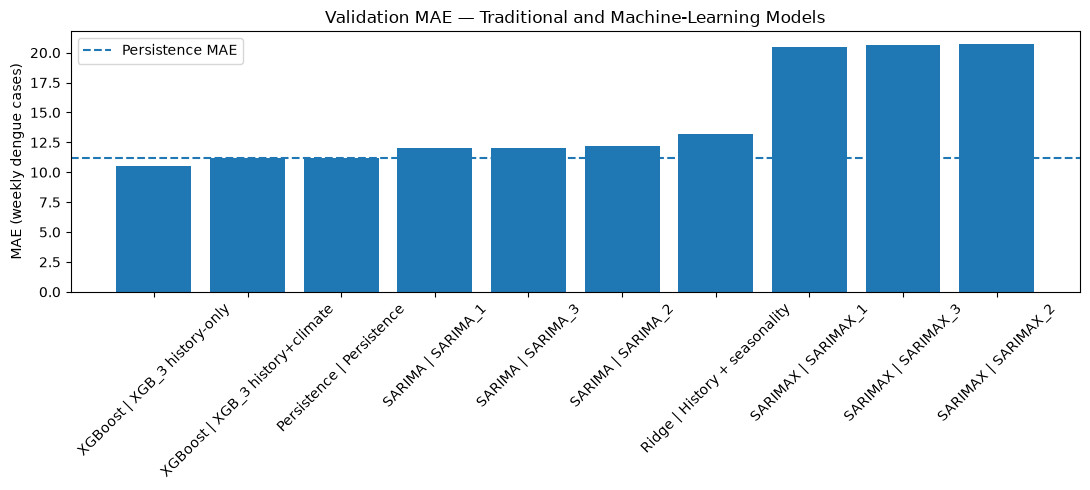

In [44]:
if STATSMODELS_AVAILABLE:

    fig, ax = plt.subplots(figsize=(11, 5))

    plot_df = comparison.sort_values("MAE").copy()
    labels = plot_df["algorithm"] + " | " + plot_df["configuration"]

    ax.bar(labels, plot_df["MAE"])
    ax.axhline(11.21, linestyle="--", label="Persistence MAE")

    ax.set_title("Validation MAE — Traditional and Machine-Learning Models")
    ax.set_ylabel("MAE (weekly dengue cases)")
    ax.tick_params(axis="x", rotation=45)
    ax.legend()

    plt.tight_layout()
    plt.show()

### Interpretation — traditional versus machine-learning models

The overall validation comparison shows a clear ranking.

The strongest model is **XGBoost history-only**, with:

- **MAE: 10.56**
- **RMSE: 21.10**
- **R²: 0.912**

The best traditional comparator, SARIMA_1, achieves:

- MAE 12.06
- RMSE 26.21
- R² 0.865

Relative to SARIMA_1, history-only XGBoost reduces MAE by roughly **12.4%** and RMSE by roughly **19.5%**.

This provides development-stage evidence in favour of H2: the machine-learning model outperforms the traditional time-series approach on all principal validation metrics.

Persistence remains a strong benchmark, but XGBoost also improves on persistence MAE.


## 11. Controlled climate contribution within SARIMA/SARIMAX

In [45]:
if STATSMODELS_AVAILABLE:

    climate_increment_rows = []

    for config in SARIMA_CONFIGS:

        sarima_name = config["name"]
        sarimax_name = sarima_name.replace("SARIMA", "SARIMAX")

        sarima_row = sarima_results_df.loc[
            sarima_results_df["configuration"] == sarima_name
        ].iloc[0]

        sarimax_row = sarimax_results_df.loc[
            sarimax_results_df["configuration"] == sarimax_name
        ].iloc[0]

        climate_increment_rows.append(
            {
                "order": str(config["order"]),
                "seasonal_order": str(config["seasonal_order"]),
                "SARIMA_MAE": sarima_row["MAE"],
                "SARIMAX_MAE": sarimax_row["MAE"],
                "MAE_change": sarimax_row["MAE"] - sarima_row["MAE"],
                "MAE_pct_change": (
                    (sarimax_row["MAE"] - sarima_row["MAE"])
                    / sarima_row["MAE"]
                    * 100
                ),
                "SARIMA_RMSE": sarima_row["RMSE"],
                "SARIMAX_RMSE": sarimax_row["RMSE"],
                "RMSE_change": sarimax_row["RMSE"] - sarima_row["RMSE"],
                "RMSE_pct_change": (
                    (sarimax_row["RMSE"] - sarima_row["RMSE"])
                    / sarima_row["RMSE"]
                    * 100
                ),
            }
        )

    sarima_climate_increment = pd.DataFrame(climate_increment_rows)
    display(sarima_climate_increment)

,order,seasonal_order,SARIMA_MAE,SARIMAX_MAE,MAE_change,MAE_pct_change,SARIMA_RMSE,SARIMAX_RMSE,RMSE_change,RMSE_pct_change
0,"(1, 0, 0)","(1, 0, 0, 52)",12.055635,20.467023,8.411388,69.771416,26.210620,32.844229,6.633609,25.308860
1,"(2, 0, 0)","(1, 0, 0, 52)",12.162887,20.747412,8.584526,70.579673,26.494423,33.322756,6.828333,25.772720
2,"(1, 0, 1)","(1, 0, 0, 52)",12.057681,20.643814,8.586134,71.208835,26.386259,33.144568,6.758309,25.612985


### Interpretation — climate contribution within SARIMA/SARIMAX

The paired comparison is unambiguous: **SARIMAX performs worse than SARIMA for every matched order**.

For the preferred `(1,0,0) × (1,0,0,52)` structure:

- MAE increases by **69.8%**
- RMSE increases by **25.3%**

The same pattern appears in the other two model structures, with MAE increases of around 70%.

Therefore, environmental variables do not provide beneficial incremental signal in this traditional exogenous time-series specification. This contrasts with Random Forest, where climate improved performance, and reinforces the conclusion that climate contribution is **model-dependent**.


## 12. Higher-incidence validation performance

In [46]:
HIGH_INCIDENCE_THRESHOLD = 179.30

def incidence_error_summary(prediction_df, algorithm, configuration):
    temp = prediction_df.copy()

    temp["absolute_error"] = (
        temp["dengue_cases"] - temp["prediction"]
    ).abs()

    temp["incidence_group"] = np.where(
        temp["dengue_cases"] >= HIGH_INCIDENCE_THRESHOLD,
        "Higher-incidence weeks",
        "Other weeks",
    )

    result = (
        temp
        .groupby("incidence_group", as_index=False)
        .agg(
            weeks=("dengue_cases", "size"),
            mean_actual_cases=("dengue_cases", "mean"),
            MAE=("absolute_error", "mean"),
        )
    )

    result["algorithm"] = algorithm
    result["configuration"] = configuration
    return result

In [47]:
if STATSMODELS_AVAILABLE:

    incidence_error_table = pd.concat(
        [
            incidence_error_summary(
                sarima_predictions[best_sarima["configuration"]],
                "SARIMA",
                best_sarima["configuration"],
            ),
            incidence_error_summary(
                sarimax_predictions[best_sarimax["configuration"]],
                "SARIMAX",
                best_sarimax["configuration"],
            ),
        ],
        ignore_index=True,
    )

    display(
        incidence_error_table[
            [
                "algorithm",
                "configuration",
                "incidence_group",
                "weeks",
                "mean_actual_cases",
                "MAE",
            ]
        ]
    )

,algorithm,configuration,incidence_group,weeks,mean_actual_cases,MAE
0,SARIMA,SARIMA_1,Higher-incidence weeks,11,276.272727,60.054469
1,SARIMA,SARIMA_1,Other weeks,145,27.144828,8.414345
2,SARIMAX,SARIMAX_1,Higher-incidence weeks,11,276.272727,72.279544
3,SARIMAX,SARIMAX_1,Other weeks,145,27.144828,16.536418


### Interpretation — higher-incidence weeks

Both traditional models struggle more during the 11 higher-incidence validation weeks, but SARIMAX performs worse in both incidence groups.

For SARIMA_1:

- higher-incidence MAE: **60.05**
- other-week MAE: **8.41**

For SARIMAX_1:

- higher-incidence MAE: **72.28**
- other-week MAE: **16.54**

Unlike the machine-learning models, adding climate does not improve the traditional model even during high-incidence weeks.

This strengthens the evidence that the usefulness of environmental information depends on how the model represents non-linear relationships and interactions.


## 13. Plot best traditional validation forecasts

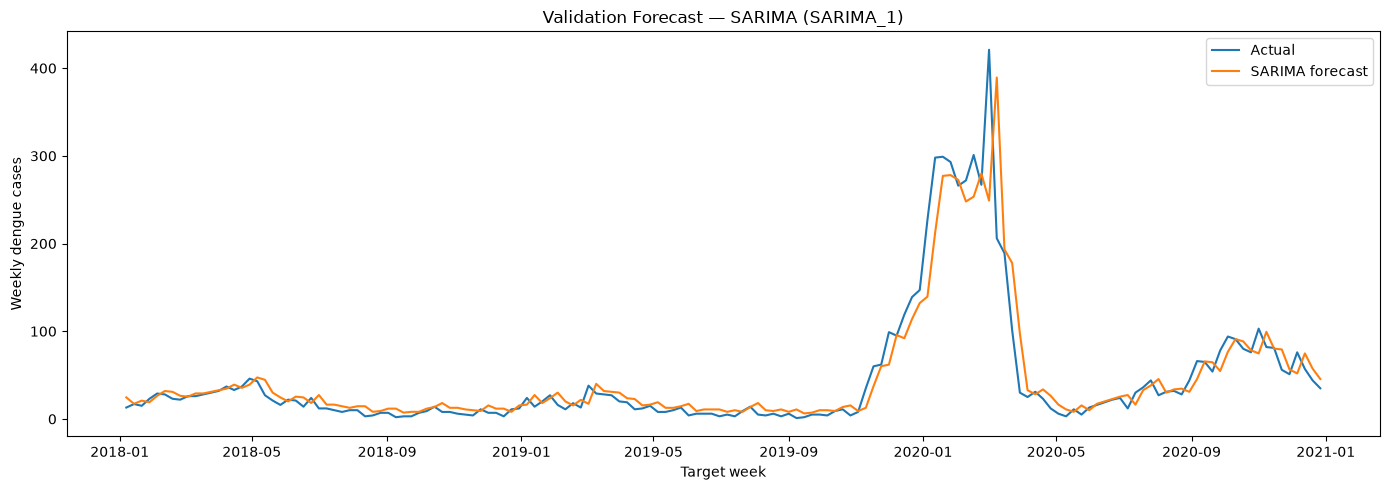

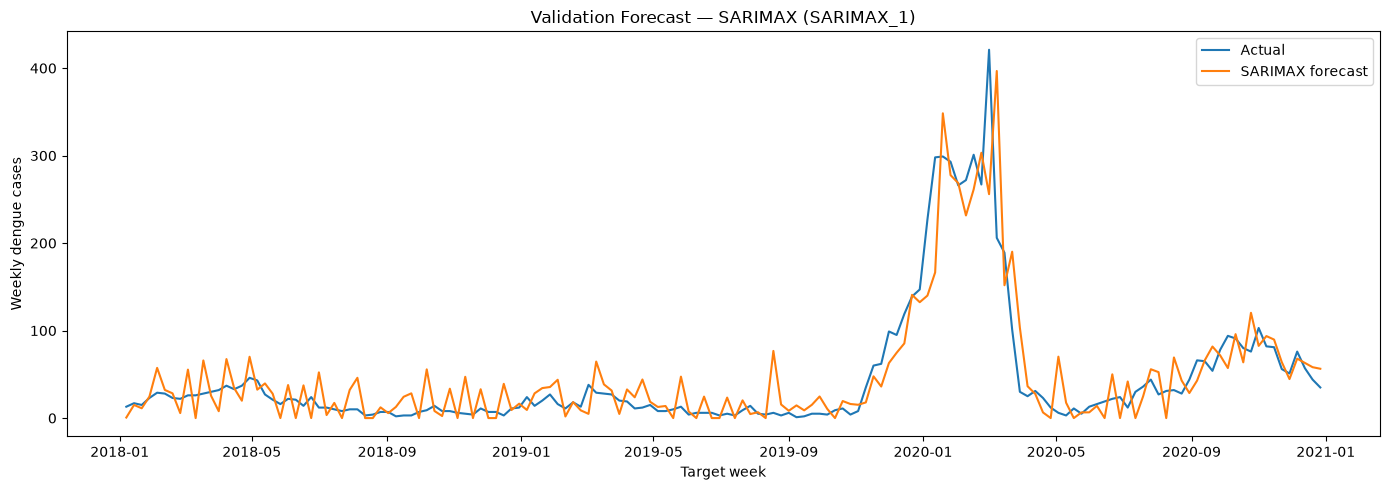

In [48]:
if STATSMODELS_AVAILABLE:

    for algorithm, configuration, pred_df in [
        (
            "SARIMA",
            best_sarima["configuration"],
            sarima_predictions[best_sarima["configuration"]],
        ),
        (
            "SARIMAX",
            best_sarimax["configuration"],
            sarimax_predictions[best_sarimax["configuration"]],
        ),
    ]:

        fig, ax = plt.subplots(figsize=(14, 5))

        ax.plot(
            pred_df["week_start_date"],
            pred_df["dengue_cases"],
            label="Actual"
        )

        ax.plot(
            pred_df["week_start_date"],
            pred_df["prediction"],
            label=f"{algorithm} forecast"
        )

        ax.set_title(
            f"Validation Forecast — {algorithm} ({configuration})"
        )
        ax.set_xlabel("Target week")
        ax.set_ylabel("Weekly dengue cases")
        ax.legend()

        plt.tight_layout()
        plt.show()

## 14. Inspect SARIMAX coefficients

In [49]:
if STATSMODELS_AVAILABLE:

    best_sarimax_model = sarimax_models[
        best_sarimax["configuration"]
    ]

    parameter_table = pd.DataFrame({
        "parameter": best_sarimax_model.params.index,
        "coefficient": best_sarimax_model.params.values,
        "p_value": best_sarimax_model.pvalues.values,
    })

    parameter_table["abs_coefficient"] = (
        parameter_table["coefficient"].abs()
    )

    display(parameter_table)

,parameter,coefficient,p_value,abs_coefficient
0,intercept,2.721283,0.995825,2.721283
1,precip_sum_mm_lag1,-0.277866,0.215388,0.277866
2,precip_sum_mm_prev4w_sum,-0.071191,0.692996,0.071191
3,temperature_c_mean_lag1,-6.670514,0.481502,6.670514
4,specific_humidity_kgkg_mean_lag1,27670.287667,0.000005,27670.287667
5,relative_humidity_pct_mean_prev4w_mean,-3.362218,0.332060,3.362218
6,wind_speed_ms_mean_lag1,9.901375,0.760866,9.901375
7,surface_pressure_hpa_mean_lag8,0.415356,0.938775,0.415356
8,ndvi_mean_weekly_lag1,-429.736066,0.281052,429.736066
9,ar.L1,0.905284,0.000000,0.905284


### Interpretation — SARIMAX coefficients

The strongest autoregressive term is `ar.L1` at approximately **0.905**, which again confirms the importance of recent dengue incidence.

Among the environmental terms, one-week lagged specific humidity has a very large positive coefficient and a very small p-value. However, the magnitude is strongly affected by its unit scale (`kg/kg`) and should not be compared directly with coefficients measured in °C, hPa, mm or NDVI units.

Most other environmental coefficients are not statistically significant in this fitted specification, and the seasonal AR(52) term is effectively zero and non-significant.

More importantly, the SARIMAX model performs substantially worse out of sample than SARIMA. Forecast validation performance should therefore take precedence over isolated coefficient significance.

These coefficients describe conditional statistical associations within this model and should not be interpreted causally.


## 15. Save development-stage outputs

In [50]:
if STATSMODELS_AVAILABLE:

    sarima_results_df.to_csv(
        OUTPUT_DIR / "sarima_validation_results.csv",
        index=False
    )

    sarimax_results_df.to_csv(
        OUTPUT_DIR / "sarimax_validation_results.csv",
        index=False
    )

    comparison.to_csv(
        OUTPUT_DIR / "traditional_ml_validation_comparison.csv",
        index=False
    )

    sarima_climate_increment.to_csv(
        OUTPUT_DIR / "sarima_sarimax_climate_increment.csv",
        index=False
    )

    incidence_error_table.to_csv(
        OUTPUT_DIR / "traditional_validation_incidence_errors.csv",
        index=False
    )

    parameter_table.to_csv(
        OUTPUT_DIR / "best_sarimax_parameters.csv",
        index=False
    )

    for name, pred_df in sarima_predictions.items():
        pred_df.to_csv(
            OUTPUT_DIR / f"{name.lower()}_validation_predictions.csv",
            index=False
        )

    for name, pred_df in sarimax_predictions.items():
        pred_df.to_csv(
            OUTPUT_DIR / f"{name.lower()}_validation_predictions.csv",
            index=False
        )

    print(
        "Traditional time-series development outputs "
        "saved to outputs/modelling/"
    )

Traditional time-series development outputs saved to outputs/modelling/


## 16. Consolidated interpretation and model-development decision

This notebook completes the development-stage comparison between traditional time-series and machine-learning forecasting approaches.

### Traditional time-series result

**SARIMA_1 `(1,0,0) × (1,0,0,52)`** is the preferred traditional comparator, with validation MAE 12.06 and RMSE 26.21.

Its performance is credible and close to persistence, but it does not match XGBoost.

### Effect of adding climate to the traditional model

SARIMAX performs substantially worse than SARIMA across every tested order.

This means climate/environmental variables do **not** consistently improve dengue forecasting. Their contribution depends on the modelling approach:

- Random Forest: climate improves overall validation performance;
- XGBoost: climate slightly worsens overall performance but improves high-incidence weeks;
- SARIMA → SARIMAX: climate substantially worsens performance.

H1 should therefore be interpreted cautiously as **mixed or partially supported**, rather than universally supported.

### Machine learning versus traditional forecasting

The strongest validation model remains **XGBoost `XGB_3` history-only**, with MAE 10.56 and RMSE 21.10.

It outperforms the best SARIMA model on MAE, RMSE and R². This provides development-stage support for H2 that machine-learning methods can outperform the traditional time-series approach for one-week-ahead dengue forecasting in this dataset.

### Models to freeze before final evaluation

The development phase should now be considered complete. The following specifications should be carried forward without further tuning:

1. **Persistence** — naïve benchmark;
2. **SARIMA_1** — traditional time-series comparator;
3. **XGB_3 history-only** — primary predictive model;
4. **XGB_3 history + climate** — direct climate-comparison model.

Random Forest can remain as supporting development evidence but does not need to be the primary final model.

### Final evaluation rule

The 2021–2023 test period should now be opened only once.

Selected models should be refitted using all information available through the end of 2020, then evaluated on the fixed 2021–2023 future holdout using:

- MAE as the primary metric;
- RMSE as the secondary metric;
- R² as supplementary context;
- descriptive higher-incidence error analysis.

No model specification should be changed in response to the final test results.
